In [167]:
from antares_devkit.models import BaseFilter
from antares_devkit.models import DevKitLocus
from antares_client import search
import numpy as np
import matplotlib.pyplot as plt
from astropy.time import Time
import pandas as pd

In [135]:
t_now = Time.now()
day_mjd = t_now.mjd-150
print(day_mjd)

61028.84609283916


In [142]:

q_hamp_trans = {
    "query": {
        "bool": {
            "filter": [
                {
                    "range": {
                        "properties.newest_alert_observation_time": {
                            "gte": day_mjd,
                        }
                    }
                },
                {
                    "range": {
                        "properties.survey.lsst.dia_object_id": {
                            "gte": 1,
                        }
                    }
                },
                {
                     "term": {
                         "tags": "high_amplitude_transient_candidate"
                     }
                }
             ]
        }
    }
}

q_hamp_vstar = {
    "query": {
        "bool": {
            "filter": [
                {
                    "range": {
                        "properties.newest_alert_observation_time": {
                            "gte": day_mjd,
                        }
                    }
                },
                {
                    "range": {
                        "properties.survey.lsst.dia_object_id": {
                            "gte": 1,
                        }
                    }
                },
                {
                     "term": {
                         "tags": "high_amplitude_variable_star_candidate"
                     }
                }
             ]
        }
    }
}


In [143]:
hamp_trans = list(search.search(q_hamp_trans))
hamp_vstar = list(search.search(q_hamp_vstar))

In [144]:
print(len(hamp_trans), len(hamp_vstar), t_now)
# hamp_vstar

16 35 2026-05-18 20:18:22.421303


this is the number of loci that were tagged with high amp transient and variable star candidates within 20 days prior to the listed date. i want to use these as a small sample to perform some tests:
- what is the difference btwn the brightest mag and the reddest bright mag (in time and intensity)?
- how drastically does the slope change to exhibit this high amplitude change?
- are any of these quasars (cross match with million quasar catalog) and if so, do we have its spectra to look at?

im going to choose a random sample to do some tests on

In [205]:
trans_test = hamp_vstar[10].to_devkit()
trans_locus = DevKitLocus.model_validate(trans_test)

In [268]:
trans_locus.lightcurve('ant_passband' == 'g')

ValueError: False not allowed as survey value

In [232]:
# trans_lc = trans_locus.lightcurve()
# trans_lc
lsst_alerts = []
for alert in trans_locus.alerts:
    if alert.properties["ant_survey"] == 4:
        lsst_alerts.append(alert.properties)
print(lsst_alerts)

[{'lsst_observation_reason': 'alert_cosmos', 'lsst_target_name': 'ddf_cosmos, lowdust', 'lsst_diaSource_diaSourceId': 170028512534069284, 'lsst_diaSource_visit': 2026021800256, 'lsst_diaSource_detector': 105, 'lsst_diaSource_diaObjectId': 170028512534069284, 'lsst_diaSource_ssObjectId': 0, 'lsst_diaSource_parentDiaSourceId': 0, 'lsst_diaSource_midpointMjdTai': 61090.189136608766, 'lsst_diaSource_ra': 150.35920302019872, 'lsst_diaSource_raErr': 2.5711062789923744e-07, 'lsst_diaSource_dec': 2.4567448878700575, 'lsst_diaSource_decErr': 2.568285424331407e-07, 'lsst_diaSource_ra_dec_Cov': -3.274671196336896e-16, 'lsst_diaSource_x': 2861.164794921875, 'lsst_diaSource_xErr': 0.004609968513250351, 'lsst_diaSource_y': 1431.923828125, 'lsst_diaSource_yErr': 0.004632926546037197, 'lsst_diaSource_centroid_flag': False, 'lsst_diaSource_apFlux': 960.1649780273438, 'lsst_diaSource_apFluxErr': 396.1449279785156, 'lsst_diaSource_apFlux_flag': False, 'lsst_diaSource_apFlux_flag_apertureTruncated': False

In [284]:

lc_1 = {'g': {'ant_mjd': [], 'ant_mag': [], 'ant_magerr': [], 'lsst_diaSource_scienceFlux': [], 'lsst_diaSource_scienceFluxErr': []}, 
         'r': {'ant_mjd': [], 'ant_mag': [], 'ant_magerr': [], 'lsst_diaSource_scienceFlux': [], 'lsst_diaSource_scienceFluxErr': []}, 
         'i': {'ant_mjd': [], 'ant_mag': [], 'ant_magerr': [], 'lsst_diaSource_scienceFlux': [], 'lsst_diaSource_scienceFluxErr': []}, 
         'z': {'ant_mjd': [], 'ant_mag': [], 'ant_magerr': [], 'lsst_diaSource_scienceFlux': [], 'lsst_diaSource_scienceFluxErr': []}}
mag = []
magerr = []
mjd = []
for alert in lsst_alerts:
    band = alert['ant_passband']
    lc_1[band]['ant_mag'].append(alert['ant_mag'])
    lc_1[band]['ant_magerr'].append(alert['ant_magerr'])
    lc_1[band]['ant_mjd'].append(alert['ant_mjd'])
    lc_1[band]['lsst_diaSource_scienceFlux'].append(alert['lsst_diaSource_scienceFlux'])
    lc_1[band]['lsst_diaSource_scienceFluxErr'].append(alert['lsst_diaSource_scienceFluxErr'])
    

now, i tried to retrieve the ant_mag_corrected from this locus, but for some reason i recieved an error when i tried to call alert['ant_mag_corrected']. how was this object tagged with this filter if the filter used ant_mag_corrected to det the mag values? what does this mean for the other objects, and for objects not tagged with this filter? idk :/// i will instead calculate the mag myself using [the eqn suggested by the lsst team](https://dp1.lsst.io/tutorials/portal/103/portal-103-3.html) (which is just the astropy flux in nJy to AB mag function)

In [274]:
print(2.5*np.log10(lc_1['g']['lsst_diaSource_scienceFlux'][0]*10**(-9)) + 31.4, lc_1['g']['ant_mag'][0])

22.10502898627169 23.361065662797174


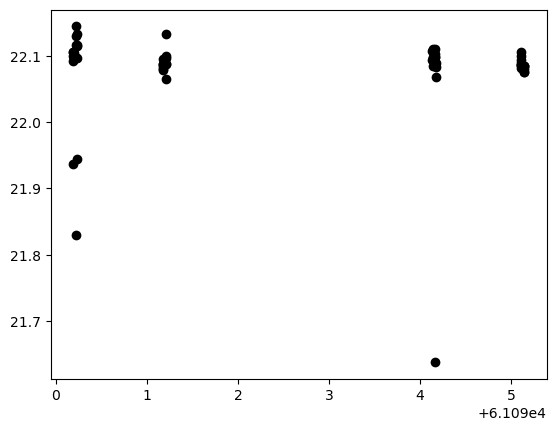

In [286]:
mag = 2.5*np.log10(np.array(lc_1['g']['lsst_diaSource_scienceFlux'])*10**(-9)) + 31.4
plt.scatter(lc_1['g']['ant_mjd'], mag, color='k')
# plt.errorbar(lc_1['g']['ant_mjd'], lc_1['g']['ant_mag'], yerr=lc_1['g']['ant_magerr'], color='k', fmt='o')
# plt.ylim(31, 21)

In [287]:
mag

array([22.10502899, 22.10039651, 22.09137969, 22.10538509, 21.93741525,
       22.10459954, 22.0986813 , 22.10176463, 22.10059202, 22.09883488,
       22.09895537, 21.82918566, 22.11556744, 22.14443546, 22.13013069,
       21.94486572, 22.13237801, 22.11514372, 22.09724386, 22.11606784,
       22.08721085, 22.09455593, 22.08636235, 22.08003385, 22.08818496,
       22.08303325, 22.07880185, 22.08802051, 22.08758923, 22.09612667,
       22.06441122, 22.13323362, 22.10022188, 22.09435834, 22.10682799,
       22.10979602, 22.09736382, 22.08423219, 22.09782906, 22.09841171,
       22.10951461, 22.10295658, 21.6376731 , 22.08789133, 22.0986583 ,
       22.0870321 , 22.08853215, 22.06803936, 22.08242772, 22.09305844,
       22.10526292, 22.08549235, 22.08179197, 22.09921672, 22.08605198,
       22.08662404, 22.08983136, 22.08493901, 22.08511088, 22.07491539,
       22.07947364, 22.07562583, 22.08442441])

In [213]:
lc = trans_lc.group_by("ant_survey")

lc.groups.keys

ant_survey
int64
1
2


i am trying to seperate out the obervations to just lsst observations, but for some reason the the lightcurve none of the rows have ant_survey = 4 (which is what is would be for LSST)

In [159]:
lsst_obs_count = 0
for alert in trans_test['alerts']:
    if alert['properties']['ant_survey'] == 4:
        lsst_obs_count += 1
print(lsst_obs_count)

673


In [115]:
hamp_cands = hamp_trans + hamp_vstar

In [194]:
hamp_cands = [hamp_vstar[0]]
for cand in hamp_cands:
    now_cand = cand.to_devkit()
    check = now_cand['old_properties']['survey']['lsst']['dia_object_id']
    if check == []:
        continue
    else:
        print(check)

['313888627082919999', '313893021775560722']
